### aim: 

### date: 

In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [2]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath

import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cmocean import cm

# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

✓ Using custom font: Gill Sans


In [3]:
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')


In [4]:
#kostelec - polsko
kostelec_6 = ['#C94B3C', '#E47A5C', '#A8B89C', '#6B9B7D', '#7FA4B8', '#4A3830']
kostelec_12 = ['#B23D32', '#C94B3C', '#E47A5C', '#D89B7A', '#E5C9A8', '#C8D4B8', '#A8B89C', '#6B9B7D', '#7FA4B8', '#5B7A8C', '#4A3830', '#2A1F1A']

#prachov - jezero 
prachovjezero_6 = ['#E85A2A', '#F4A63D', '#6B8C3E', '#5B9BAD', '#4A6B8A', '#6B3428']
prachovjezero_12 = ['#D84B28', '#E85A2A', '#F27435', '#F4A63D', '#D4B665', '#89A648', '#6B8C3E', '#4E7054', '#5B9BAD', '#4A6B8A', '#6B3428', '#3D2820']

# Tatry 
tatry_6 = ['#9B7850', '#D4C8A8', '#5B7F68', '#7BA6BC', '#A8BECF', '#3A4F3C']
tatry_12 = ['#7A5F40', '#9B7850', '#C4B090', '#E5D8B8', '#B8D090', '#8FAB80', '#5B7F68', '#5B7B7C', '#7BA6BC', '#A8BECF', '#3A4F3C', '#2B3A2E']
#cesky raj
ceskyraj_6 = ['#B8734E', '#D4A562', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#3A2F28']
ceskyraj_12 = ['#A85C3C', '#B8734E', '#D49558', '#D4A562', '#E5C485', '#9CB68A', '#6B8B72', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#5B3F4A', '#3A2F28']

## prachov - skaly
prachovskaly_6 = ['#B8844E', '#D4A865', '#6B8B5C', '#4B7B8C', '#2B5B8C', '#1B3F5C']
prachovskaly_12 = ['#9B6B3C', '#B8844E', '#C89B5A', '#D4A865', '#E5C68A', '#8BA872', '#6B8B5C', '#4B6B5A', '#5B8B9C', '#4B7B8C', '#2B5B8C', '#1B3F5C']

## jested lanovka
jested_6 = ['#D86B45', '#D4B870', '#8FAB7C', '#5B7B8C', '#6B8BAC', '#3A5B48']
jested_12 = ['#C85B3A', '#D86B45', '#E59B58', '#D4B870', '#E5D090', '#B8C88C', '#8FAB7C', '#6B8B78', '#5B7B8C', '#6B8BAC', '#4B6B5C', '#3A5B48']

## krkonose 
krkonose_6 = ['#E5A542', '#C4D858', '#6B8B5C', '#4B6B8C', '#7A9BAC', '#8B6B47']
krkonose_12 = ['#B87A3C', '#E5A542', '#F5C855', '#D4DB6A', '#C4D858', '#A8C850', '#6B8B5C', '#5B7B6C', '#4B6B8C', '#7A9BAC', '#8B6B47', '#5B4B38']

## dumbier
dumbier_6 = ['#D87845', '#E5C8A0', '#4B7BC2', '#6B9BD8', '#7AB8E5', '#1A2B3A']
dumbier_12 = ['#C86838', '#D87845', '#E59B68', '#E5C8A0', '#F5E8D0', '#A8C8E5', '#7AB8E5', '#6B9BD8', '#4B7BC2', '#3A5B8C', '#2A3B5C', '#1A2B3A']

## assorted snippets

#### netcdf

In [5]:
sav = False
if sav:
    savenam = 'test2.nc'
    data_vars = {'vomecrty':(['time_counter', 'depthv', 'y', 'x'], vomecrty.values,
    {'units': 'µatm',
    'long_name':'Surface ocean pCO2'}),
    }
    # define coordinates
    coords = {'time_counter': (['time_counter'], time_counter),
            'time_centered': (['time_centered'], time_centered),
    'nav_lat': (['y','x'], nav_lat),
    'nav_lon': (['y','x'], nav_lon),
    'depthv': (['depthv'], depthv)}
    # define global attributes
    attrs = {'made in':'SOZONE/MEDUSA/makeYearlyMEDUSAsubsetfiles.ipynb',
    'desc': 'yearly medusa files, saving only variables of interest'
    }
    ds = xr.Dataset(data_vars=data_vars,
    coords=coords,
    attrs=attrs)
    ds.to_netcdf(savenam)

#### tylist

In [6]:
def make_yearlist(yrst, yrend, dtype, tr, baseDir):
    yrs = np.arange(yrst,yrend+1,1)
    ylist = []
    for i in range(0,len(yrs)):
        ty = f'{baseDir}/{tr}/ORCA2_1m_{yrs[i]}*{dtype}*.nc'
        t2 = glob.glob(ty)
        #print(t2)
        ylist.append(t2[0])
    return ylist

## does rui have more phosphorus kicking around? (no, even less :()

In [20]:
## LA50, LAH3 ## RY_ERA3
baseDir = '/gpfs/data/greenocean/software/runs/'

RY_ERA3_20 = xr.open_mfdataset(make_yearlist(2015, 2024, 'ptrc', 'TOM12_RY_ERA3', baseDir))
RY_ERA3_55 = xr.open_mfdataset(make_yearlist(1950, 1959, 'ptrc', 'TOM12_RY_ERA3', baseDir))
TJ_LAH3_20 = xr.open_mfdataset(make_yearlist(2015, 2024, 'ptrc', 'TOM12_TJ_LAH3', baseDir))
TJ_LAH3_55 = xr.open_mfdataset(make_yearlist(1950, 1959, 'ptrc', 'TOM12_TJ_LAH3', baseDir))

## BOE - print out mean area-weighted values

In [69]:
RY_ERA3_55.PO4

mm_tom = xr.open_dataset('/gpfs/data/greenocean/software/resources/regrid/mesh_mask3_6.nc')
mm_tom['area'] = mm_tom.tmask[0,0,:,:] * mm_tom.e1t[0,:,:] * mm_tom.e2t[0,:,:]


print(TJ_LAH3_55.PO4.isel(deptht=0).isel(time_counter=0).weighted(mm_tom['area']).mean(dim = ['x','y']).values)

tdir = '/gpfs/home/avd22gnu/scratch/WOA/scripts'
obs_N = xr.open_dataset(f'{tdir}/woa18_all_n00_01_regridORCA_converted.nc', decode_times=False)
obs_P = xr.open_dataset(f'{tdir}/woa18_all_p00_01_regridORCA_converted.nc', decode_times=False)

print(obs_N.n_an.isel(z=0).isel(time_counter=0).weighted(mm_tom['area']).mean(dim = ['x','y']).values)

5.8581862593790816e-05
5.151885300299398e-06


## maps from a model

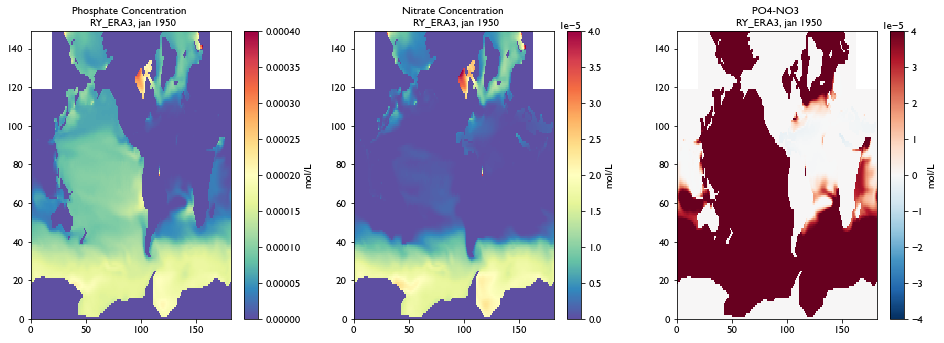

In [9]:
fact = 0.7
fig, axes = plt.subplots(1, 3, figsize=(19*fact, 7*fact))
axes = axes.ravel()

tmod = RY_ERA3_55
q = axes[0].pcolormesh(tmod.PO4.values[0,0,:,:], vmin = 0, vmax = 4e-4, cmap = 'Spectral_r')
plt.colorbar(q, ax = axes[0], label = f'{tmod.PO4.units}')
axes[0].set_title(f'{tmod.PO4.long_name} \n RY_ERA3, jan 1950')

i = 1
q = axes[i].pcolormesh(tmod.NO3.values[0,0,:,:], vmin = 0, vmax = 4e-5, cmap = 'Spectral_r')
plt.colorbar(q, ax = axes[i], label = f'{tmod.NO3.units}')
axes[i].set_title(f'{tmod.NO3.long_name} \n RY_ERA3, jan 1950')

i = 2
q = axes[i].pcolormesh(tmod.PO4.values[0,0,:,:]-tmod.NO3.values[0,0,:,:], \
                       vmin = -4e-5, vmax = 4e-5, cmap = 'RdBu_r')
plt.colorbar(q, ax = axes[i], label = f'{tmod.NO3.units}')
axes[i].set_title(f'PO4-NO3 \n RY_ERA3, jan 1950')

# q = axes[1].pcolormesh(wn.n_an.values[0,0,:,:], vmin = 0, vmax = 30, cmap = 'Spectral')
# plt.colorbar(q, ax = axes[1], label = f'{wn.n_an.units}')
# axes[1].set_title(f'{wn.n_an.standard_name}')
plt.tight_layout()
plt.savefig('./plts/RY_ERA3-NP.png')

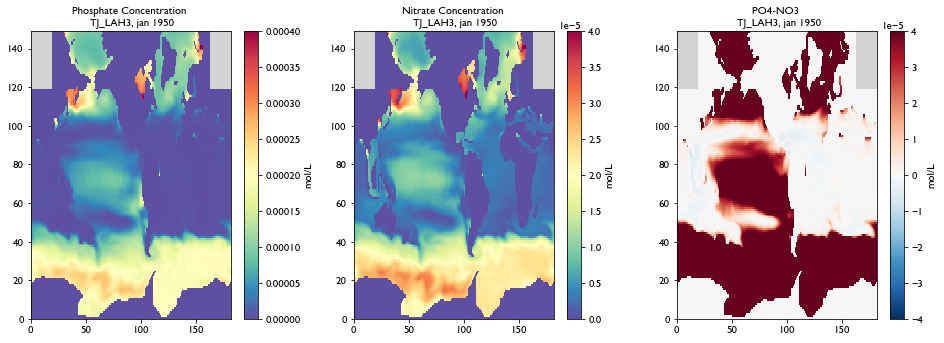

In [130]:
fact = 0.7
fig, axes = plt.subplots(1, 3, figsize=(19*fact, 7*fact))
axes = axes.ravel()

tmod = TJ_LAH3_55
q = axes[0].pcolormesh(tmod.PO4.values[0,0,:,:], vmin = 0, vmax = 4e-4, cmap = 'Spectral_r')
plt.colorbar(q, ax = axes[0], label = f'{tmod.PO4.units}')
axes[0].set_title(f'{tmod.PO4.long_name} \n TJ_LAH3, jan 1950')

i = 1
q = axes[i].pcolormesh(tmod.NO3.values[0,0,:,:], vmin = 0, vmax = 4e-5, cmap = 'Spectral_r')
plt.colorbar(q, ax = axes[i], label = f'{tmod.NO3.units}')
axes[i].set_title(f'{tmod.NO3.long_name} \n TJ_LAH3, jan 1950')

i = 2
q = axes[i].pcolormesh(tmod.PO4.values[0,0,:,:]-tmod.NO3.values[0,0,:,:], \
                       vmin = -4e-5, vmax = 4e-5, cmap = 'RdBu_r')
plt.colorbar(q, ax = axes[i], label = f'{tmod.NO3.units}')
axes[i].set_title(f'PO4-NO3 \n TJ_LAH3, jan 1950')

# q = axes[1].pcolormesh(wn.n_an.values[0,0,:,:], vmin = 0, vmax = 30, cmap = 'Spectral')
# plt.colorbar(q, ax = axes[1], label = f'{wn.n_an.units}')
# axes[1].set_title(f'{wn.n_an.standard_name}')
plt.tight_layout()
plt.savefig('./plts/TJ_LAH3-NP.png')

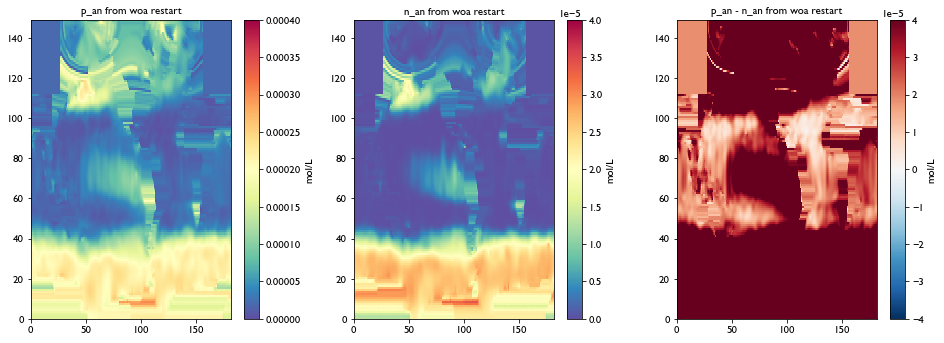

In [124]:

fact = 0.7
fig, axes = plt.subplots(1, 3, figsize=(19*fact, 7*fact))
axes = axes.ravel()


i = 0
q = axes[i].pcolormesh(obs_P.p_an.isel(z = 0, time_counter = 0), vmin = 0, vmax = 4e-4, cmap = 'Spectral_r')
plt.colorbar(q, ax = axes[i], label = f'mol/L')
axes[i].set_title(f'p_an from woa restart')


i = 1
q = axes[i].pcolormesh(obs_N.n_an.isel(z = 0, time_counter = 0), vmin = 0, vmax = 4e-5, cmap = 'Spectral_r')
plt.colorbar(q, ax = axes[i], label = f'mol/L')
axes[i].set_title(f'n_an from woa restart')

i = 2
q = axes[i].pcolormesh(obs_P.p_an.isel(z = 0, time_counter = 0) - \
                       obs_N.n_an.isel(z = 0, time_counter = 0), vmin = -4e-5, vmax = 4e-5, cmap = 'RdBu_r')
plt.colorbar(q, ax = axes[i], label = f'mol/L')
axes[i].set_title(f'p_an - n_an from woa restart')

# i = 1
# q = axes[i].pcolormesh(tmod.NO3.values[0,0,:,:], vmin = 0, vmax = 4e-5, cmap = 'Spectral_r')
# plt.colorbar(q, ax = axes[i], label = f'{tmod.NO3.units}')
# axes[i].set_title(f'{tmod.NO3.long_name} \n RY_ERA3, jan 1950')

# i = 2
# q = axes[i].pcolormesh(tmod.PO4.values[0,0,:,:]-tmod.NO3.values[0,0,:,:], \
#                        vmin = -4e-5, vmax = 4e-5, cmap = 'RdBu_r')
# plt.colorbar(q, ax = axes[i], label = f'{tmod.NO3.units}')
# axes[i].set_title(f'PO4-NO3 \n RY_ERA3, jan 1950')

# q = axes[1].pcolormesh(wn.n_an.values[0,0,:,:], vmin = 0, vmax = 30, cmap = 'Spectral')
# plt.colorbar(q, ax = axes[1], label = f'{wn.n_an.units}')
# axes[1].set_title(f'{wn.n_an.standard_name}')
plt.tight_layout()
plt.savefig('./plts/woa_planktom_restart.png')

## WOA downloaded vals

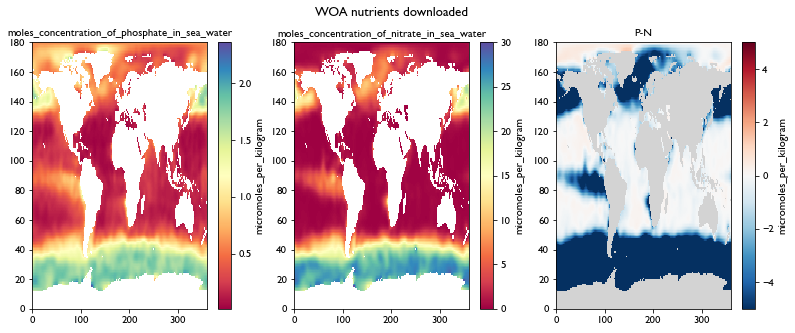

In [129]:
wn = xr.open_dataset('./data/woa18_all_n00_01.nc', decode_times=False)
wp = xr.open_dataset('./data/woa18_all_p00_01.nc', decode_times=False)

fig, axes = plt.subplots(1, 3, figsize=(19*fact, 7*fact))
axes = axes.ravel()

q = axes[0].pcolormesh(wp.p_an.values[0,0,:,:], cmap = 'Spectral')
plt.colorbar(q, ax = axes[0], label = f'{wp.p_an.units}')
axes[0].set_title(f'{wp.p_an.standard_name}')

q = axes[1].pcolormesh(wn.n_an.values[0,0,:,:], vmin = 0, vmax = 30, cmap = 'Spectral')
plt.colorbar(q, ax = axes[1], label = f'{wn.n_an.units}')
axes[1].set_title(f'{wn.n_an.standard_name}')


q = axes[2].pcolormesh(wp.p_an.values[0,0,:,:] - wn.n_an.values[0,0,:,:], vmin = -5, vmax = 5, cmap = 'RdBu_r')
plt.colorbar(q, ax = axes[2], label = f'{wn.n_an.units}')
axes[2].set_title(f'P-N')
plt.suptitle('WOA nutrients downloaded')
plt.savefig('./plts/woa_raw.png')

## maps of surface climatologies

In [49]:
obs_nut = xr.open_dataset('./data/obs_surface_nut.nc')
RY_ERA3_nut = xr.open_dataset('./data/RY_ERA3_surface_nut.nc')
TJ_LAH3_nut = xr.open_dataset('./data/TJ_LAH3_surface_nut.nc')

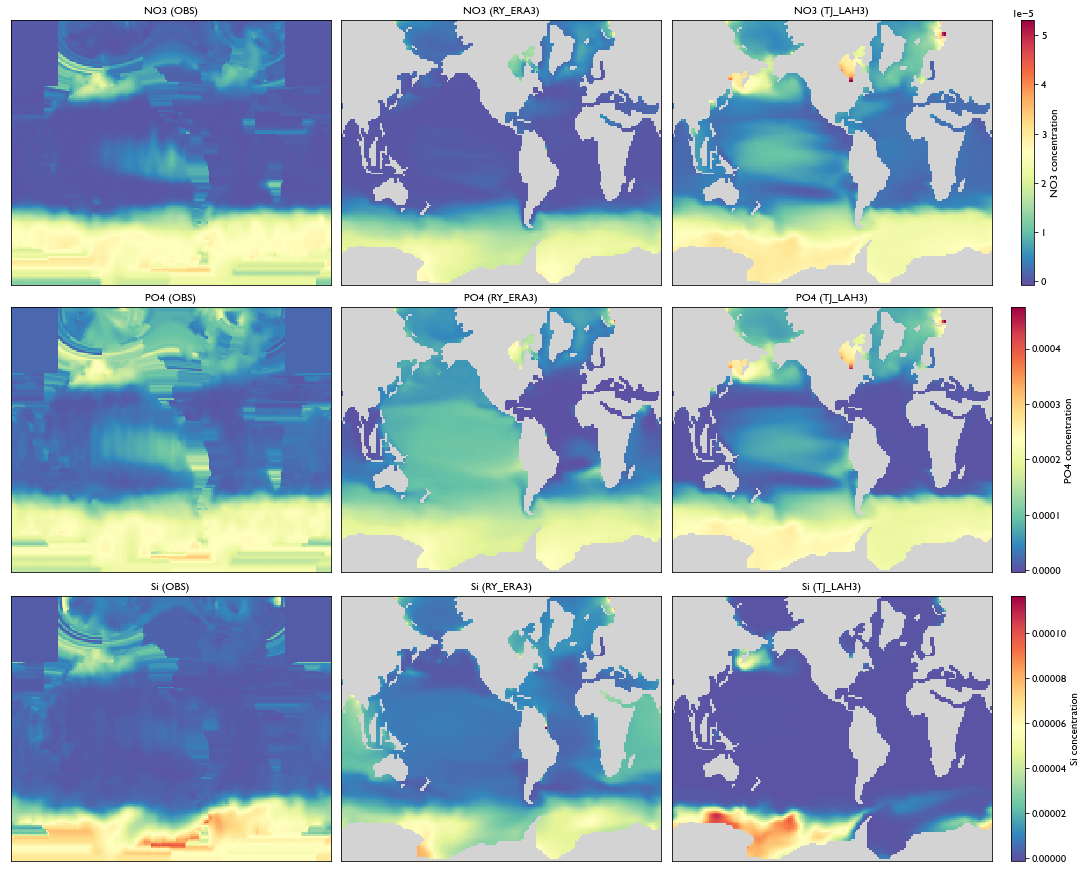

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# ----------------------------------------------------------
# Helper: convert zeros to NaN
# ----------------------------------------------------------
def mask_zeros(arr):
    arr = arr.astype(float)
    arr[arr == 0] = np.nan
    return arr

# ----------------------------------------------------------
# Variables (nutrients)
# ----------------------------------------------------------
nutrients = ["NO3", "PO4", "Si"]

# List of datasets in column order
datasets = [
    ("OBS", obs_nut),
    ("RY_ERA3", RY_ERA3_nut),
    ("TJ_LAH3", TJ_LAH3_nut)
]

# ----------------------------------------------------------
# Create figure
# ----------------------------------------------------------
fig, axes = plt.subplots(
    nrows=3, ncols=3,
    figsize=(15, 12),
    constrained_layout=True
)

# ----------------------------------------------------------
# Colormap for data
# ----------------------------------------------------------
cmap_main = plt.cm.Spectral_r
cmap_main.set_bad("lightgrey")

# ----------------------------------------------------------
# Loop through nutrients (each row)
# ----------------------------------------------------------
for i, var in enumerate(nutrients):

    # ------------------------------------------
    # Compute global vmin/vmax for THIS nutrient
    # across all 3 datasets
    # ------------------------------------------
    values = []
    for name, ds in datasets:
        values.append(ds[var].values)

    vmin = float(np.nanmin(values))
    vmax = float(np.nanmax(values)) * 0.8

    # ------------------------------------------
    # Plot each of the 3 datasets
    # ------------------------------------------
    ims = []

    for j, (name, ds) in enumerate(datasets):
        data = mask_zeros(ds[var].values)

        im = axes[i, j].pcolormesh(
            data, cmap=cmap_main, vmin=vmin, vmax=vmax
        )
        ims.append(im)

        axes[i, j].set_title(f"{var} ({name})")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

    # ------------------------------------------
    # ONE COLORBAR PER ROW
    # ------------------------------------------
    fig.colorbar(
        ims[0],              # any of the 3 (they share scaling)
        ax=axes[i, :],       # spans entire row
        orientation='vertical',
        pad=0.02,
        fraction=0.04,
        label=f"{var} concentration"
    )

plt.show()


## check raw woa vals
    
    why are we always going on a beginner friendly trip about longitude and latitude

In [70]:
savenam = '/gpfs/home/mep22dku/scratch/SOZONE/windAnalyis/wspdComponents/PlankTOMmask_regridrecalc.nc'
cdomask = xr.open_dataset(savenam)
tmask = cdomask.tmask

cdomask['lon'] = xr.where(cdomask['lon'] > 180, cdomask['lon'] - 360, cdomask['lon'])
cdomask['lon'] = xr.where(cdomask['lon'] > 180, cdomask['lon'] - 360, cdomask['lon'])
cdomask['lon'] = cdomask['lon'] - 0.5
cdomask = cdomask.sortby(['lon','lat'])
#mm_rg['area'] = mm_rg['aream2'][0,:,:]
#mm_med['area'] = mm_med.tmask[0,:,:] * mm_med.e1t[:,:] * mm_med.e2t[:,:]

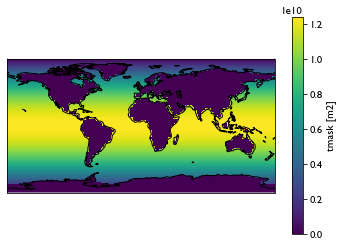

In [55]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
ds = cdomask
# Create a plot with a specific projection
ax = plt.axes(projection=ccrs.PlateCarree())
# or other projections like:
# ax = plt.axes(projection=ccrs.Mollweide())
# ax = plt.axes(projection=ccrs.Robinson())

# Plot your data
ds['tmask'].plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()
plt.show()

Text(0.5, 1.0, 'moles_concentration_of_nitrate_in_sea_water')

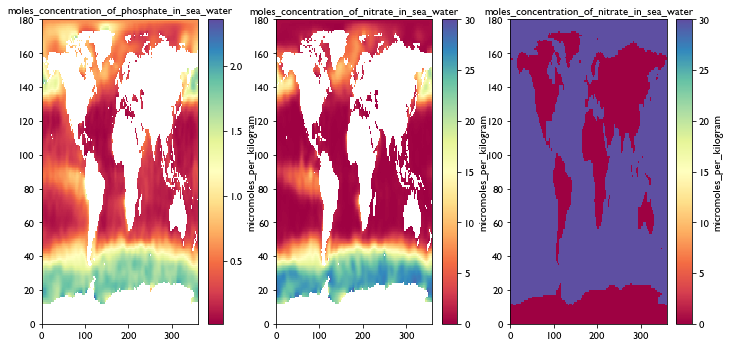

In [61]:
wn = xr.open_dataset('./data/woa18_all_n00_01.nc', decode_times=False)
wp = xr.open_dataset('./data/woa18_all_p00_01.nc', decode_times=False)

fact = 0.7
fig, axes = plt.subplots(1, 3, figsize=(17*fact, 8*fact))

q = axes[0].pcolormesh(wp.p_an.values[0,0,:,:], cmap = 'Spectral')
plt.colorbar(q, ax = axes[0], label = f'{wp.p_an.units}')
axes[0].set_title(f'{wp.p_an.standard_name}')

q = axes[1].pcolormesh(wn.n_an.values[0,0,:,:], vmin = 0, vmax = 30, cmap = 'Spectral')
plt.colorbar(q, ax = axes[1], label = f'{wn.n_an.units}')
axes[1].set_title(f'{wn.n_an.standard_name}')


q = axes[2].pcolormesh(cdomask.tmask[:,:], vmin = 0, vmax = 30, cmap = 'Spectral')
plt.colorbar(q, ax = axes[2], label = f'{wn.n_an.units}')
axes[2].set_title(f'{wn.n_an.standard_name}')

## weighted raw vals

In [66]:
wp.p_an[0,0,:,:]

print(wn.n_an.isel(time=0).isel(depth=0).weighted(cdomask.tmask).mean(dim = ['lat','lon']).values)

5.061920579315403


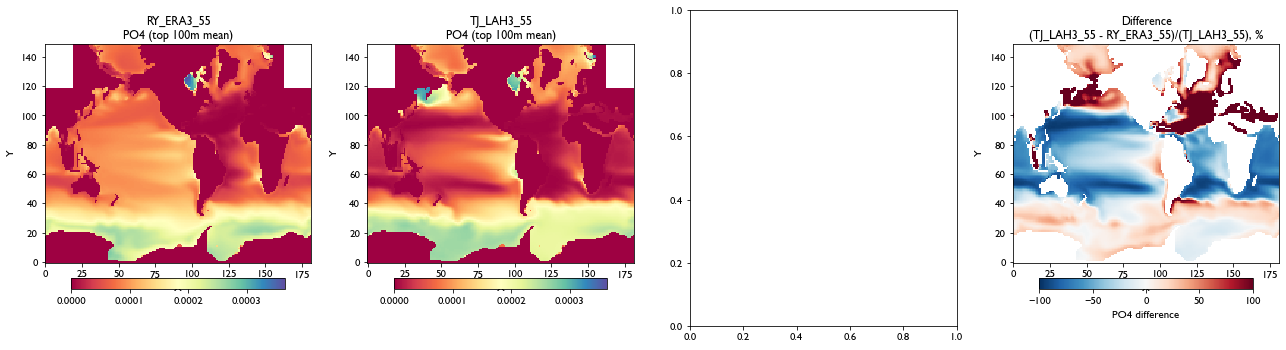

## what about nitrogen? 

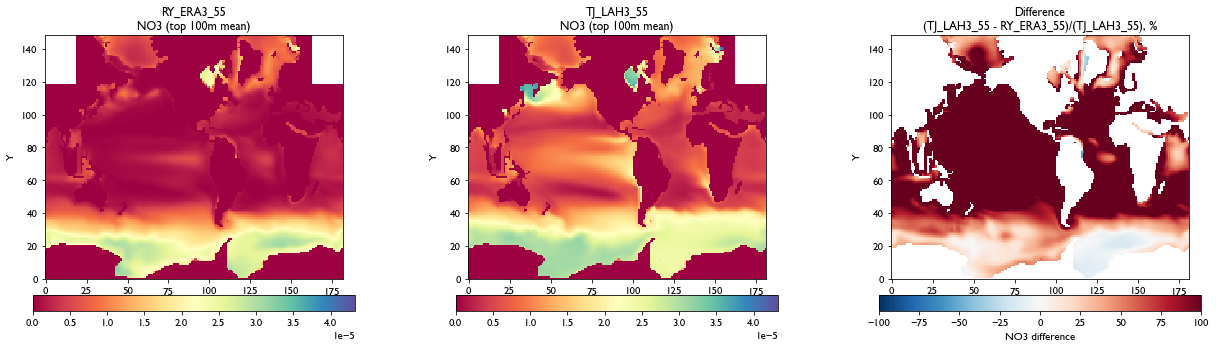

In [9]:
# Assuming RY_ERA3_55 and TJ_LAH3_55 are already loaded xarray datasets
# If not, load them first:
# RY_ERA3_55 = xr.open_dataset('path_to_RY_ERA3_55.nc')
# TJ_LAH3_55 = xr.open_dataset('path_to_TJ_LAH3_55.nc')

# Variable to plot (change this to any variable in your dataset)
variable = 'NO3'

# Select top 100 meters and compute time mean
# Adjust depth dimension name if needed (could be 'deptht', 'depth', 'z', etc.)
run1 = RY_ERA3_55[variable].sel(deptht=slice(0, 100)).mean(dim=['deptht', 'time_counter'])
run2 = TJ_LAH3_55[variable].sel(deptht=slice(0, 100)).mean(dim=['deptht', 'time_counter'])

# Calculate difference
diff = run2 - run1

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Common colorbar limits for run1 and run2
vmin_runs = min(run1.min().values, run2.min().values)
vmax_runs = max(run1.max().values, run2.max().values)

# Difference colorbar limits (symmetric around zero)
vmax_diff = max(abs(diff.min().values), abs(diff.max().values))
vmin_diff = -vmax_diff

# Plot 1: RY_ERA3_55
ax1 = axes[0]
im1 = ax1.pcolormesh(run1.x, run1.y, run1, 
                      cmap='Spectral', vmin=vmin_runs, vmax=vmax_runs, shading='auto')
ax1.set_title(f'RY_ERA3_55\n{variable} (top 100m mean)', fontsize=12, fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_aspect('equal')
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)

# Plot 2: TJ_LAH3_55
ax2 = axes[1]
im2 = ax2.pcolormesh(run2.x, run2.y, run2, 
                      cmap='Spectral', vmin=vmin_runs, vmax=vmax_runs, shading='auto')
ax2.set_title(f'TJ_LAH3_55\n{variable} (top 100m mean)', fontsize=12, fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_aspect('equal')
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)

# Plot 3: Difference (TJ_LAH3_55 - RY_ERA3_55)
ax3 = axes[2]
im3 = ax3.pcolormesh(diff.x, diff.y, (diff/run1)*100, 
                      cmap='RdBu_r', vmin=-100, vmax=100, shading='auto')
ax3.set_title(f'Difference\n(TJ_LAH3_55 - RY_ERA3_55)/(TJ_LAH3_55), %', fontsize=12, fontweight='bold')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_aspect('equal')
plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.8, 
             label=f'{variable} difference')

plt.tight_layout()
plt.savefig(f'{variable}_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## ok what about future? 

In [10]:
def compute_province_means(dataset, tmesh, provinces, tvars=None, depth_max=100):
    """
    Compute area-weighted province means for specified variables.
    
    Parameters:
    -----------
    dataset : xarray.Dataset
        Input dataset with variables to process
    tmesh : xarray.Dataset
        Mesh dataset containing province masks and cell sizes
    provinces : list
        List of province names to process
    tvars : list of str, optional
        List of variable names to process. If None, processes all variables.
        Example: ['PO4', 'NO3', 'Fe', 'Si']
    depth_max : float, optional
        Maximum depth in meters to average over (default: 100)
        Set to None to use all depths without averaging
    
    Returns:
    --------
    xarray.Dataset
        Combined dataset with province means
    """
    # If no variables specified, use all variables in dataset
    if tvars is None:
        tvars = list(dataset.data_vars)
    
    results = {}
    for prov in provinces:
        # Get the mask for this province from tmesh (assuming it's at [0,0,:,:])
        prov_mask = tmesh[prov][0,0,:,:]
        # Create weighted mask: area * binary mask
        weighted_mask = tmesh.csize * prov_mask
        # Sum of weights for normalization
        total_weight = weighted_mask.sum(dim=['y', 'x'])
        # Apply area-weighted mean to specified variables only
        prov_means = {}
        for var in tvars:
            if var in dataset.data_vars:
                data = dataset[var]
                
                # Average over top depth_max meters if depth dimension exists
                if depth_max is not None and 'deptht' in data.dims:
                    data = data.sel(deptht=slice(0, depth_max)).mean(dim='deptht')
                
                weighted_data = data * weighted_mask
                prov_means[var] = weighted_data.sum(dim=['y', 'x']) / total_weight
            else:
                print(f"Warning: Variable '{var}' not found in dataset, skipping.")
        results[prov] = xr.Dataset(prov_means)
    # Combine all provinces into one dataset
    combined = xr.concat([results[prov] for prov in provinces], 
                         dim=xr.DataArray(provinces, dims='province', name='province'))
    return combined

In [11]:
tvars = ['PO4', 'NO3', 'Fer', 'Si']
tmesh = xr.open_dataset('/gpfs/data/greenocean/software/resources/regrid/mesh_mask3_6.nc')
atl = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/data/meshmask_with_Atl.nc')

# Calculate cell sizes
atl['csize'] = atl.tmask[0,0,:,:] * atl.e1t[0,:,:] * atl.e2t[0,:,:]
tmesh = atl

provinces = ['NAT', 'NAL', 'NAM', 'NAH']

# RY_ERA3_20 = xr.open_mfdataset(make_yearlist(2015, 2024, 'ptrc', 'TOM12_RY_ERA3', baseDir))
# RY_ERA3_55 = xr.open_mfdataset(make_yearlist(1950, 1959, 'ptrc', 'TOM12_RY_ERA3', baseDir))
# TJ_LAH3_20 = xr.open_mfdataset(make_yearlist(2015, 2024, 'ptrc', 'TOM12_TJ_LAH3', baseDir))
# TJ_LAH3_55 = xr.open_mfdataset(make_yearlist(1950, 1959, 'ptrc', 'TOM12_TJ_LAH3', baseDir))

RY_ERA3_20_pm = compute_province_means(RY_ERA3_20, tmesh, provinces, tvars=tvars, depth_max=100)
RY_ERA3_55_pm = compute_province_means(RY_ERA3_55, tmesh, provinces, tvars=tvars, depth_max=100)
TJ_LAH3_20_pm = compute_province_means(TJ_LAH3_20, tmesh, provinces, tvars=tvars, depth_max=100)
TJ_LAH3_55_pm = compute_province_means(TJ_LAH3_55, tmesh, provinces, tvars=tvars, depth_max=100)

In [13]:
horse = False
if horse: 
    import matplotlib.pyplot as plt
    import numpy as np
    import xarray as xr

    # Define dataset styles - easily customizable
    dataset_styles = {
        'RY_ERA3_20': {'color': '#1f77b4', 'linestyle': '-', 'label': 'RY_ERA3_20'},
        'RY_ERA3_55': {'color': '#1f77b4', 'linestyle': '-', 'label': 'RY_ERA3_55'},
        'TJ_LAH3_20': {'color': '#d62728', 'linestyle': '-', 'label': 'TJ_LAH3_20'},
        'TJ_LAH3_55': {'color': '#d62728', 'linestyle': ':', 'label': 'TJ_LAH3_55'}
    }

    # Province and variable order
    provinces = ['NAH', 'NAM', 'NAL', 'NAT']
    variables = ['PO4', 'NO3', 'Si', 'Fer']

    # Store datasets in a dictionary for easy iteration
    datasets = {
        'RY_ERA3_20': RY_ERA3_20_pm,
        'RY_ERA3_55': RY_ERA3_55_pm,
        'TJ_LAH3_20': TJ_LAH3_20_pm,
        'TJ_LAH3_55': TJ_LAH3_55_pm
    }

    # Create figure with 16 subplots (4 rows x 4 columns)
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))

    # Plot each combination
    for i, prov in enumerate(provinces):
        for j, var in enumerate(variables):
            ax = axes[i, j]

            # Plot each dataset
            for ds_name, ds in datasets.items():
                # Select data for this province and variable
                data = ds[var].sel(province=prov)

                # Compute yearly average
                # Group by year and take mean
                data_yearly = data.groupby('time_counter.year').mean()

                # Plot with specified style
                style = dataset_styles[ds_name]
                ax.plot(data_yearly.year, data_yearly,
                       color=style['color'],
                       linestyle=style['linestyle'],
                       label=style['label'],
                       linewidth=2)

            # Formatting
            ax.set_title(f'{prov} - {var}', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_xlabel('Year')
            ax.set_ylabel(f'{var} concentration')

            # Add legend only to top-right subplot
            if i == 0 and j == 3:
                ax.legend(loc='best', fontsize=10)

    # Adjust layout
    plt.tight_layout()
    plt.savefig('province_nutrient_timeseries.png', dpi=300, bbox_inches='tight')
    plt.show()

# bordel

In [71]:
ex = False

if ex:
    
    tdir = '/gpfs/home/avd22gnu/scratch/WOA/scripts'
    obs_N = xr.open_dataset(f'{tdir}/woa18_all_n00_01_regridORCA_converted.nc', decode_times=False)
    obs_P = xr.open_dataset(f'{tdir}/woa18_all_p00_01_regridORCA_converted.nc', decode_times=False)
    obs_S = xr.open_dataset(f'{tdir}/woa18_all_i00_01_regridORCA_converted.nc', decode_times=False)
    
    
    obs_N_s = obs_N.n_an.isel(z = 0, time_counter = 0)
    obs_P_s = obs_P.p_an.isel(z = 0, time_counter = 0)
    obs_S_s = obs_S.i_an.isel(z = 0, time_counter = 0)


    q = ['Alkalini','O2','DIC','PIIC','MAC',
        'DOC','CaCO3','ARA','POC','GOC','HOC','BAC','PRO','PTE','MES','GEL','CRU',
        'DIA','MIX','COC','PIC','PHA','FIX','BSi','GON','C11','B14B','C14B','D14B'
    ]

    RY_ERA3_55 = RY_ERA3_55.drop_vars(q, errors = 'ignore')
    TJ_LAH3_55 = TJ_LAH3_55.drop_vars(q, errors = 'ignore')

    RY_ERA3_55_mn = RY_ERA3_55.isel(deptht = 0).mean(dim = 'time_counter')
    TJ_LAH3_55_mn = TJ_LAH3_55.isel(deptht = 0).mean(dim = 'time_counter')

    obs_c = xr.merge([obs_N_s,obs_P_s,obs_S_s])
    obs_c = obs_c.rename({'n_an': 'NO3', 'p_an': 'PO4', 'i_an' : 'Si'})

    obs_c.to_netcdf('./data/obs_surface_nut.nc')
    RY_ERA3_55_mn.to_netcdf('./data/RY_ERA3_surface_nut.nc')
    TJ_LAH3_55_mn.to_netcdf('./data/TJ_LAH3_surface_nut.nc')

In [ ]:
    # Assuming RY_ERA3_55 and TJ_LAH3_55 are already loaded xarray datasets
    # If not, load them first:
    # RY_ERA3_55 = xr.open_dataset('path_to_RY_ERA3_55.nc')
    # TJ_LAH3_55 = xr.open_dataset('path_to_TJ_LAH3_55.nc')

    # Variable to plot (change this to any variable in your dataset)
    variable = 'PO4'

    # Select top 100 meters and compute time mean
    # Adjust depth dimension name if needed (could be 'deptht', 'depth', 'z', etc.)
    run1 = RY_ERA3_55[variable].sel(deptht=slice(0, 100)).mean(dim=['deptht', 'time_counter'])
    run2 = TJ_LAH3_55[variable].sel(deptht=slice(0, 100)).mean(dim=['deptht', 'time_counter'])

    # Calculate difference
    diff = run2 - run1

    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    # Common colorbar limits for run1 and run2
    vmin_runs = min(run1.min().values, run2.min().values)
    vmax_runs = max(run1.max().values, run2.max().values)

    # Difference colorbar limits (symmetric around zero)
    vmax_diff = max(abs(diff.min().values), abs(diff.max().values))
    vmin_diff = -vmax_diff

    # Plot 1: RY_ERA3_55
    ax1 = axes[0]
    im1 = ax1.pcolormesh(run1.x, run1.y, run1, 
                          cmap='Spectral', vmin=vmin_runs, vmax=vmax_runs, shading='auto')
    ax1.set_title(f'RY_ERA3_55\n{variable} (top 100m mean)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_aspect('equal')
    plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)

    # Plot 2: TJ_LAH3_55
    ax2 = axes[1]
    im2 = ax2.pcolormesh(run2.x, run2.y, run2, 
                          cmap='Spectral', vmin=vmin_runs, vmax=vmax_runs, shading='auto')
    ax2.set_title(f'TJ_LAH3_55\n{variable} (top 100m mean)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_aspect('equal')
    plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)

    # Plot 3: Difference (TJ_LAH3_55 - RY_ERA3_55)
    ax3 = axes[3]
    im3 = ax3.pcolormesh(diff.x, diff.y, (diff/run1)*100, 
                          cmap='RdBu_r', vmin=-100, vmax=100, shading='auto')
    ax3.set_title(f'Difference\n(TJ_LAH3_55 - RY_ERA3_55)/(TJ_LAH3_55), %', fontsize=12, fontweight='bold')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.set_aspect('equal')
    plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.8, 
                 label=f'{variable} difference')

    plt.tight_layout()
    #plt.savefig(f'{variable}_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()